# Has Q2 revenue kept pace with the plan line week by week, and where did it stand at mid-quarter?

**Week 2, Wednesday. Chapter 5 of 6.** Chapters 1 to 4 looked at members; this chapter
looks at the quarter, for Meera.

> "And Meera wants to see revenue accumulate week by week against the plan line, so we know
> by mid-quarter whether we are on track."
> The marketing lead, Kalpa Retail, passing on Meera Raghavan's ask

**Who needs the answer.** Meera Raghavan, CEO of Kalpa Retail, decides at mid-quarter whether
to change course: hold the plan, push a campaign or move budget. A quarter reported behind
plan when it is on plan sends Marketing after a gap that is not there, with discounts that
cost margin; a quarter read as comfortably ahead when one week made the lead hides a run rate
below plan until the quarter is gone.

**The questions on the way.**
1. Which ways could the team accumulate the quarter against plan, and what would each cost?
2. How much had Q2 booked by the end of each plan week?
3. Does the running total close on Monday's Q2 total?
4. Where did Q2 stand at mid-quarter, and how has each week run since?
5. Can a running total by order say which order took Q2 past Rs 3.5 crore?
6. Does a plain sum up to each week's end agree?

**The metric at stake.** Booked revenue to date against plan to date. Booked revenue is
every order at its amount whatever its status, and Monday's suite put Q2, July to September
2026, at Rs 9,84,00,000. The plan line is a small table, `plan_line`, with one row per plan
week: the Monday it starts and the revenue planned for it. To date means every week up to
and including the one on the row. The retail dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, says in section 4 what
Meera Raghavan owns as CEO, the growth plan and where money is spent, and in section 5 how
revenue is worked out, branch by branch.

**What chapters 1 to 4 found.** Each segment's protect list is its top fifty by Q2 revenue
under RANK, and 16 members' spend fell in September and in the month before it. A running
total is a window too: `sum(x) OVER (ORDER BY week)` keeps every week's row and carries the
sum of every row up to and including it.

**A real company with the same question.** Target's second quarter of 2022 began on 1 May
2022. On 7 June 2022, about five weeks in, Target said it "now expects its second-quarter
operating margin rate will be in a range around 2%", down from a range centred on the first
quarter's 5.3 percent, after markdowns to clear excess inventory (Target's releases of 7
June and 18 May 2022, checked 1 October 2026). The quarter closed at 1.2 percent (Target's
release of 17 August 2022). Meera's week-by-week line asks for the same early reading of
Kalpa's Q2.

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D03_05_against_plan_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D03_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def rows(query):
    """Run a query and hand back its rows with every number as a Python number."""
    return [{k: num(v) for k, v in r.items()} for r in kit.sql(query)]

def show(found, caption="", money=(), limit=12):
    """Rows as the kit's table, with the columns named in money set in rupees."""
    if not found:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(found[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in found[:limit]]
    if len(found) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12, echo=True):
    """Print a named block, run it, show its rows and hand them back."""
    if echo:
        print(Q[name])
    found = rows(Q[name])
    show(found, caption, money, limit)
    return found

def lakh(v):
    """Rupees in lakh, for an axis that has to hold Business and retail members at once."""
    return f"{v / 100000:,.1f} lakh"

Q = blocks("05_against_plan")
print(len(Q), "named queries read from", "C2_W02_D03_05_against_plan_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

9 named queries read from C2_W02_D03_05_against_plan_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


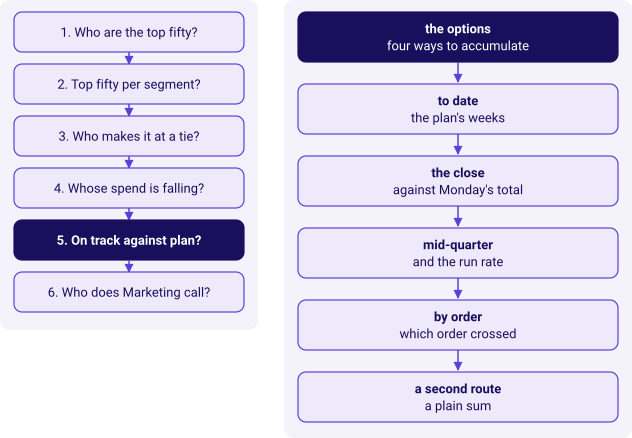

In [2]:
kit.side_by_side(
    kit.ladder(['Who are the top fifty?', 'Top fifty per segment?', 'Who makes it at a tie?', 'Whose spend is falling?', 'On track against plan?', 'Who does Marketing call?'], lit=4, show=False),
    kit.vflow(['the options\nfour ways to accumulate', "to date\nthe plan's weeks", "the close\nagainst Monday's total", 'mid-quarter\nand the run rate', 'by order\nwhich order crossed', 'a second route\na plain sum'], lit=0, show=False),
)

## The options: which ways could the team accumulate the quarter against plan, and what would each cost?

| Option | How it accumulates | What the database works through | Statements | When it fits |
|---|---|---|---|---|
| A. A running SUM in a window over weekly totals | weekly totals first, then `sum() OVER (ORDER BY week)` for booked and for plan | the Q2 orders once, then 13 weeks | 1 | a to-date figure at every week, in one table |
| B. A plain SUM up to each week's end | for each plan week, sums every order dated up to its last day | the Q2 orders once per plan week | 1, with a subquery per week | one reading on one date Meera names |
| C. A self-join of weeks to every earlier week | joins each week to itself and every week before, then GROUP BY | the week pairs | 1 | a database with no window functions |
| D. A spreadsheet with a cumulative column | exports the orders and copies a formula down | every Q2 order, exported | none | a one-off look nobody reruns |

**Predict before you run.** How many order rows does option B read to fill all thirteen plan
weeks?

- a) 462, the Q2 orders once.
- b) 13, one per week.
- c) About 6,000.
- d) About 91.

option,rows or pairs worked through
A. running SUM in a window,462
B. plain SUM per week,"6,006"
C. self-join of weeks,91
D. spreadsheet export,462


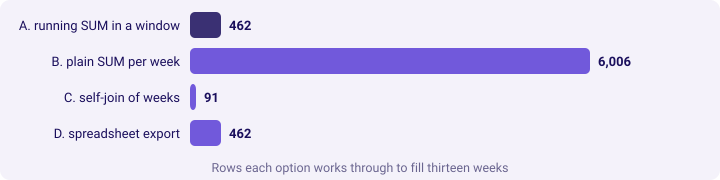

In [3]:
plan = rows(Q["c5_plan"])
span = rows(Q["c5_q2_span"])[0]
weeks = len(plan)
sizing = [("A. running SUM in a window", span["orders"]), ("B. plain SUM per week", weeks * span["orders"]),
          ("C. self-join of weeks", weeks * (weeks + 1) // 2), ("D. spreadsheet export", span["orders"])]
kit.table(["option", "rows or pairs worked through"], [(o, f"{n:,}") for o, n in sizing],
          caption=f"Sized on Q2: {span['orders']} orders and {weeks} plan weeks")
kit.bars(sizing, title="Rows each option works through to fill thirteen weeks", lit=(0,))

**What happened.** The answer is c: 6,006 order reads, the 462 Q2 orders once for each of the
13 plan weeks. The window reads the orders once and accumulates 13 weekly totals; the
self-join works through 91 week pairs; the spreadsheet exports all 462 orders, which the data
platform lead's rule, "query it, do not export it", rules out.

**The best-fit call.** Option A, a running SUM in a window, booked and plan side by side in
one table. **What would change the call:** a single reading on a day Meera names, such as
"where were we on 19 August?", which is one plain SUM with the date in WHERE, option B for
one week.

In [4]:
kit.check("thirteen plan weeks", weeks == 13)
kit.check("option B reads 6,006 order rows", weeks * span["orders"] == 6006)
kit.check("the plan adds to Rs 9,83,99,990", sum(p["plan_revenue"] for p in plan) == 98399990)

## 1. How much had Q2 booked by the end of each plan week?

The plan line holds 13 weeks from Monday 6 July, Rs 75,69,230 each. The quickest build starts
from the plan's weeks, attaches each week's booked revenue by the Monday its orders fall in,
`date_trunc('week', order_date)`, and accumulates both sides:

```sql
FROM plan_line p LEFT JOIN weekly w USING (week_start)
...
sum(plan_revenue) OVER (ORDER BY week_start) AS plan_to_date,
sum(booked)       OVER (ORDER BY week_start) AS booked_to_date
```

**Predict before you run.** Where does booked to date finish against the plan to date of
Rs 9,83,99,990?

- a) On plan, within a few rupees.
- b) About Rs 15 lakh short of plan.
- c) About Rs 1.6 crore ahead.
- d) Nine times the plan.

-- The hurried build: start from the plan's weeks, attach each week's booked revenue by the Monday
-- its orders fall in, and accumulate both sides.
WITH weekly AS (
    SELECT date_trunc('week', order_date)::date AS week_start,
           sum(amount)                          AS booked
    FROM   orders
    WHERE  quarter = 'Q2'
    GROUP  BY 1
),
joined AS (
    SELECT p.week_start, p.plan_revenue, coalesce(w.booked, 0) AS booked
    FROM   plan_line p
    LEFT   JOIN weekly w USING (week_start)
)
SELECT week_start,
       sum(plan_revenue) OVER (ORDER BY week_start) AS plan_to_date,
       sum(booked)       OVER (ORDER BY week_start) AS booked_to_date
FROM   joined
ORDER  BY week_start;


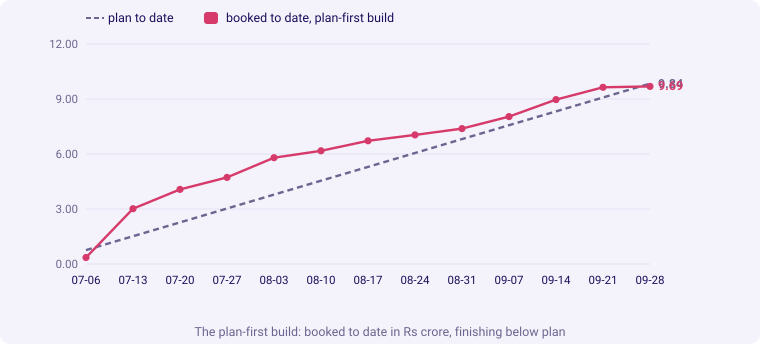

In [5]:
print(Q["c5_plan_first"])
hurried = rows(Q["c5_plan_first"])
kit.line([str(r["week_start"])[5:] for r in hurried],
         [("plan to date", [r["plan_to_date"] / 1e7 for r in hurried], "plan"),
          ("booked to date, plan-first build", [r["booked_to_date"] / 1e7 for r in hurried], "bad")],
         title="The plan-first build: booked to date in Rs crore, finishing below plan",
         fmt=lambda v: f"{v:.2f}")
last = hurried[-1]
kit.stats([(kit.rupees(last["booked_to_date"]), "booked to date", "the plan-first build's close"),
           (kit.rupees(last["plan_to_date"]), "plan to date", "thirteen weeks"),
           (kit.rupees(last["plan_to_date"] - last["booked_to_date"]), "short of plan", "as the table reports it")],
          caption="The plausible wrong answer at the close")

**The plausible wrong answer.** Q2 closed at Rs 9,68,60,180 against a plan of Rs 9,83,99,990,
Rs 15,39,810 short. The answer to the prediction, as the table reports it, is b. Sent to
Meera, that line says the quarter missed plan, and the next quarter opens on a campaign to
recover Rs 15 lakh.

## 2. Does the running total close on Monday's Q2 total?

**Why it is wrong.** Every rupee of Q2 should be in the last row of a running total.
Monday's suite put Q2 at Rs 9,84,00,000, and the table's last booked to date is short of it.

**The check that exposes it.** Set the last booked to date beside the quarter's own total,
then ask which Mondays Q2's orders fall under.

In [6]:
q2_total = span["q2_revenue"]
q2_weeks = run("c5_weeks_of_q2", "Q2's orders by the Monday each falls under", money=("booked",), echo=False, limit=4)
before = rows(Q["c5_before_plan"])[0]
kit.check("the plan-first close is short of Q2's own total", last["booked_to_date"] < q2_total,
          f"{kit.rupees(q2_total - last['booked_to_date'])} missing")
kit.check("Q2's orders fall under 14 Mondays, the plan has 13", len(q2_weeks) == 14 and weeks == 13)
kit.check("the missing rupees are the orders before the plan's first week",
          q2_total - last["booked_to_date"] == before["booked"], f"{before['orders']} orders")

week_start,orders,booked
2026-06-29,25,"Rs 15,39,820"
2026-07-06,38,"Rs 35,60,360"
2026-07-13,37,"Rs 2,66,28,920"
2026-07-20,43,"Rs 1,05,15,380"
...,...,...


**What happened.** The close is Rs 15,39,820 short of Q2's own total, and the rupees are not
lost: Q2 starts on Wednesday 1 July and the plan's first week on Monday 6 July. The 25 orders
of 1 to 5 July, Rs 15,39,820, fall under Monday 29 June, a week the plan line does not have,
and a LEFT JOIN that starts from the plan's weeks keeps only the plan's weeks. Tuesday's rule
holds here too: a join is done only when its rows are explained, and this one dropped 25
orders without a word.

**The fix, and what it changed.** The plan's first week carries the Q2 days before it.
`greatest(date_trunc('week', order_date), first plan Monday)` moves the orders of 1 to 5 July
onto 6 July, so every Q2 order lands in a plan week.

-- The fix: the plan's first week carries the Q2 days before it, so every Q2 order lands in a plan
-- week. greatest() moves the days before the first plan Monday onto that Monday.
WITH weekly AS (
    SELECT greatest(date_trunc('week', order_date)::date,
                    (SELECT min(week_start) FROM plan_line)) AS week_start,
           sum(amount)                                      AS booked
    FROM   orders
    WHERE  quarter = 'Q2'
    GROUP  BY 1
),
joined AS (
    SELECT p.week_start, p.plan_revenue, coalesce(w.booked, 0) AS booked
    FROM   plan_line p
    LEFT   JOIN weekly w USING (week_start)
)
SELECT week_start,
       week_start + 6                               AS week_end,
       plan_revenue,
       booked,
       sum(plan_revenue) OVER (ORDER BY week_start) AS plan_to_date,
       sum(booked)       OVER (ORDER BY week_start) AS booked_to_date
FROM   joined
ORDER  BY week_start;


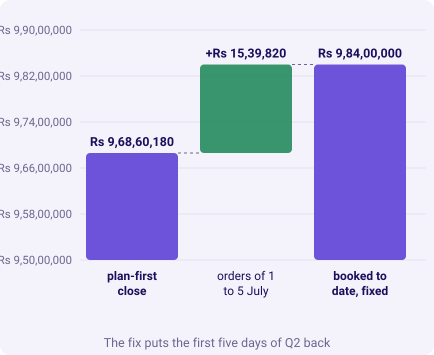

In [7]:
print(Q["c5_fixed"])
fixed = rows(Q["c5_fixed"])
close = fixed[-1]
kit.bridge(("plan-first close", last["booked_to_date"]), [("orders of 1 to 5 July", before["booked"])],
           end_label="booked to date, fixed", title="The fix puts the first five days of Q2 back",
           fmt=kit.rupees, lo=9.5e7)
kit.check("the fixed close is Monday's Rs 9,84,00,000", close["booked_to_date"] == q2_total == 98400000)
kit.check("Q2 closes Rs 10 ahead of plan", close["booked_to_date"] - close["plan_to_date"] == 10)

**What happened.** Booked to date now closes on Rs 9,84,00,000, Monday's total, against a plan
of Rs 9,83,99,990: Q2 finished Rs 10 ahead, on plan, where the plan-first build reported it
Rs 15,39,810 short. The bridge's axis starts at Rs 9.5 crore so the move shows.

## 3. Where did Q2 stand at mid-quarter, and how has each week run since?

Mid-quarter is the end of the seventh of thirteen plan weeks, the week of 17 August.

**Predict before you run.** At the end of the week of 17 August, where was booked to date
against plan to date?

- a) About Rs 15 lakh behind.
- b) About Rs 1.6 crore ahead.
- c) Exactly on plan.
- d) About nine times the plan.

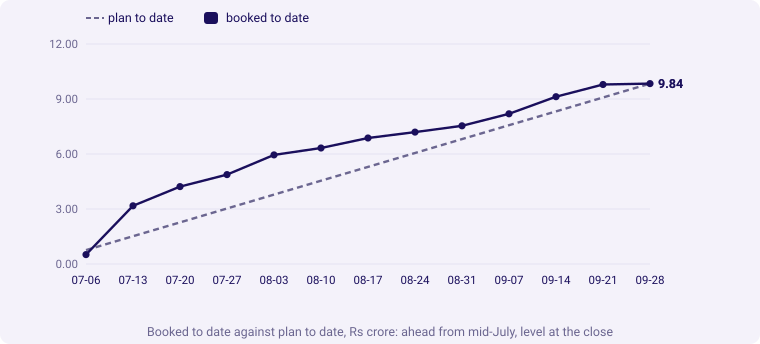

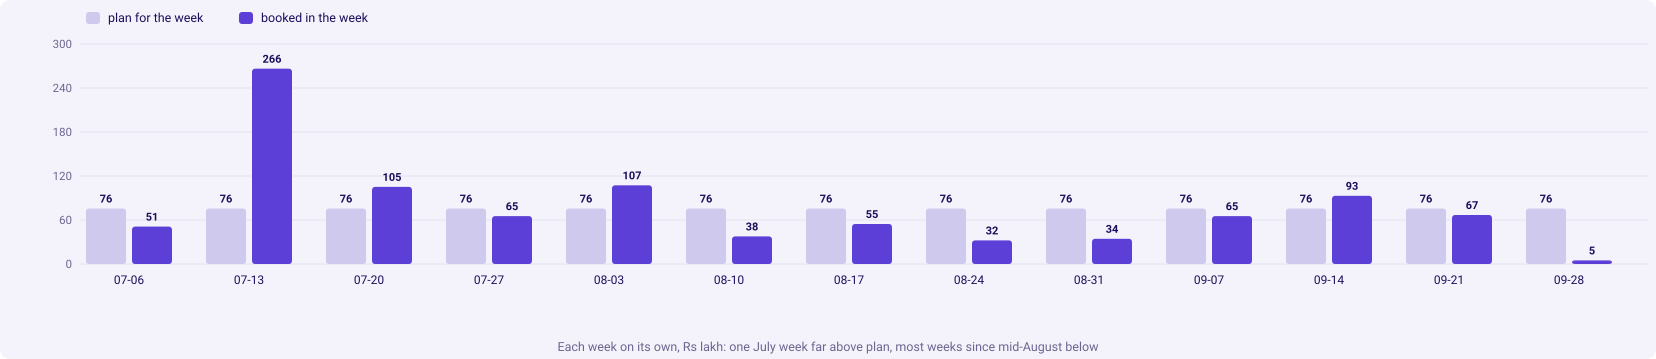

In [8]:
mid = fixed[6]
kit.line([str(r["week_start"])[5:] for r in fixed],
         [("plan to date", [r["plan_to_date"] / 1e7 for r in fixed], "plan"),
          ("booked to date", [r["booked_to_date"] / 1e7 for r in fixed], "lit")],
         title="Booked to date against plan to date, Rs crore: ahead from mid-July, level at the close",
         fmt=lambda v: f"{v:.2f}")
kit.columns([str(r["week_start"])[5:] for r in fixed],
            [("plan for the week", [r["plan_revenue"] / 1e5 for r in fixed]),
             ("booked in the week", [r["booked"] / 1e5 for r in fixed])],
            title="Each week on its own, Rs lakh: one July week far above plan, most weeks since mid-August below",
            fmt=lambda v: f"{v:,.0f}")

**What happened.** The answer is b. At the end of the week of 17 August, booked to date was
Rs 6,87,36,590 against a plan to date of Rs 5,29,84,610, Rs 1,57,51,980 ahead. On its own,
the week of 13 July booked Rs 2,66,28,920, three and a half times its plan of Rs 75,69,230,
and from the week of 10 August six of the seven full weeks booked below their plan. The
quarter was ahead by the total and behind by the run rate, and it closed level because one
July week paid for the weeks after it.

A cumulative figure set beside one week's plan reads Rs 6,87,36,590 against Rs 75,69,230 at
mid-quarter, about nine times plan, which is option d; booked to date belongs beside plan to
date.

In [9]:
full_since = [r for r in fixed if "2026-08-10" <= str(r["week_start"]) <= "2026-09-21"]
kit.check("mid-quarter is Rs 1,57,51,980 ahead", mid["booked_to_date"] - mid["plan_to_date"] == 15751980)
kit.check("six of the seven full weeks from 10 August booked below plan",
          sum(r["booked"] < r["plan_revenue"] for r in full_since) == 6 and len(full_since) == 7)
kit.check("the week of 13 July booked Rs 2,66,28,920", fixed[1]["booked"] == 26628920)

## 4. Can a running total by order say which order took Q2 past Rs 3.5 crore?

At the grain of a week, every row has its own Monday, so the order of the window is never in
doubt. At the grain of an order it is: 22 July, the busiest day of Q2, holds twelve orders.
Rows that share the window's ORDER BY value are peers, and the default running sum adds all
of a row's peers at once.

**Predict before you run.** With `sum(amount) OVER (ORDER BY order_date)`, what does the first
order of 22 July show?

- a) Rs 3,45,16,000, the day before plus its own amount.
- b) Rs 3,76,90,290, the day's closing total.
- c) Its own amount.
- d) NULL.

order_id,amount,by_date_alone,by_date_and_id
KR-00557,Rs 930,"Rs 3,76,90,290","Rs 3,45,16,000"
KR-00580,"Rs 8,55,000","Rs 3,76,90,290","Rs 3,53,71,000"
KR-00601,"Rs 10,40,000","Rs 3,76,90,290","Rs 3,64,11,000"
KR-00604,"Rs 10,42,000","Rs 3,76,90,290","Rs 3,74,53,000"
KR-00607,"Rs 2,21,000","Rs 3,76,90,290","Rs 3,76,74,000"
KR-00713,"Rs 3,240","Rs 3,76,90,290","Rs 3,76,77,240"
KR-00761,"Rs 2,520","Rs 3,76,90,290","Rs 3,76,79,760"
KR-00782,"Rs 2,250","Rs 3,76,90,290","Rs 3,76,82,010"
KR-00832,"Rs 2,920","Rs 3,76,90,290","Rs 3,76,84,930"
KR-00853,"Rs 2,150","Rs 3,76,90,290","Rs 3,76,87,080"


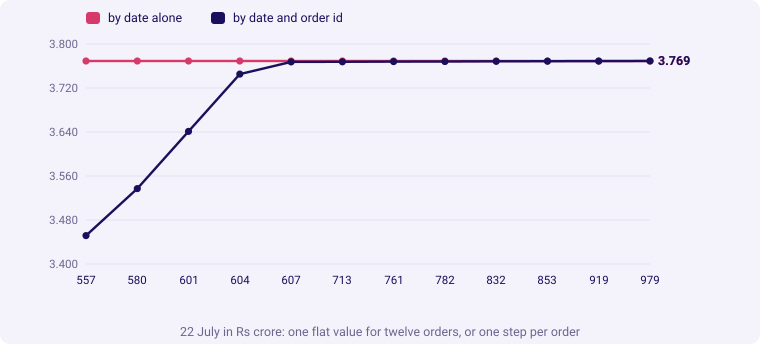

In [10]:
peers = run("c5_peers", "22 July: a running total by date alone, and by date and order id",
            money=("amount", "by_date_alone", "by_date_and_id"), echo=False)
kit.line([r["order_id"][-3:] for r in peers],
         [("by date alone", [r["by_date_alone"] / 1e7 for r in peers], "bad"),
          ("by date and order id", [r["by_date_and_id"] / 1e7 for r in peers], "lit")],
         title="22 July in Rs crore: one flat value for twelve orders, or one step per order",
         fmt=lambda v: f"{v:.3f}", lo=3.4)

**What happened.** The answer is b: by date alone, all twelve orders of 22 July show
Rs 3,76,90,290, the day's closing total, so no row can say which order crossed Rs 3.5 crore.
With the order id added to the ORDER BY, every row is its own step, from Rs 3,45,16,000 to
Rs 3,76,90,290, and the step past Rs 3.5 crore is KR-00580's, Rs 8,55,000. The order id makes
the running total the same on every run and on every learner's machine; it does not make it
the true order of the day, since the warehouse records a date and no time. Say which tiebreak
the figure uses.

In [11]:
kit.check("by date alone, the twelve orders share one value", len({r["by_date_alone"] for r in peers}) == 1 and len(peers) == 12)
kit.check("by date and id, every order has its own value", len({r["by_date_and_id"] for r in peers}) == 12)
kit.check("both versions finish the day on the same total", peers[-1]["by_date_alone"] == peers[-1]["by_date_and_id"])

## A second route: does a plain sum up to each week's end agree?

Option B, with no window: for each plan week, one plain SUM of every Q2 order dated on or
before the week's last day. It reads the orders 13 times, and it shares no code with the
window or with the `greatest()` fix.

**Predict before you run.** Will the thirteen plain sums match the fixed running total week by
week?

- a) Yes, all thirteen.
- b) All but the first week, which the sums miss.
- c) Only the last week.
- d) None, since a plain SUM cannot accumulate.

In [12]:
plain = rows(Q["c5_second_route"])
kit.table(["week starting", "running SUM in a window", "plain SUM to the week's end"],
          [(str(f["week_start"]), kit.rupees(f["booked_to_date"]), kit.rupees(p["booked_to_date"]))
           for f, p in zip(fixed, plain)][:5] + [("...", "...", "...")],
          caption="Two routes, week by week (first five of thirteen)")
kit.check("the two routes agree in all thirteen weeks",
          [f["booked_to_date"] for f in fixed] == [p["booked_to_date"] for p in plain])

week starting,running SUM in a window,plain SUM to the week's end
2026-07-06,"Rs 51,00,180","Rs 51,00,180"
2026-07-13,"Rs 3,17,29,100","Rs 3,17,29,100"
2026-07-20,"Rs 4,22,44,480","Rs 4,22,44,480"
2026-07-27,"Rs 4,87,81,050","Rs 4,87,81,050"
2026-08-03,"Rs 5,95,15,810","Rs 5,95,15,810"
...,...,...


**What happened.** The answer is a: the plain sums equal the window's running total in all
thirteen weeks, including the first, since the first week's last day, 12 July, already
includes 1 to 5 July. The plain sums read 6,006 order rows to say what the window said in one
pass, which is why they are the check.

> **Kavya's review.** A running total is finished when its last value equals the total you can
> count without it. Close the loop on Monday's Rs 9,84,00,000 before you say ahead or behind.

### In the interview: what makes a running total trustworthy?

**[F] What makes a running total deterministic, and how would you notice one that was not?**
Its ORDER BY has to be unique within the window, such as the date plus the order id. Rows
that share an ORDER BY value are peers and show the same cumulative figure, which is the
tell: a flat run of identical values across rows, or a figure that cannot say which row
crossed a line.

**[D] Your running total closes below the quarter's total. What do you check first?** Check
whether every row made it in: compare the last cumulative value with the independent total,
then look for rows outside the join's calendar, such as days before the first plan week or
after the last. Here 25 orders of 1 to 5 July were missing, Rs 15,39,820.

**[F] A dashboard says revenue to date is nine times the plan by week seven. What is the likely
mistake?** The likely mistake is a cumulative actual set beside one week's plan. Accumulate
the plan too and compare to date with to date: at mid-quarter that is Rs 6,87,36,590 against
Rs 5,29,84,610.

### Depth: how far ahead was Q2 at the end of every plan week?

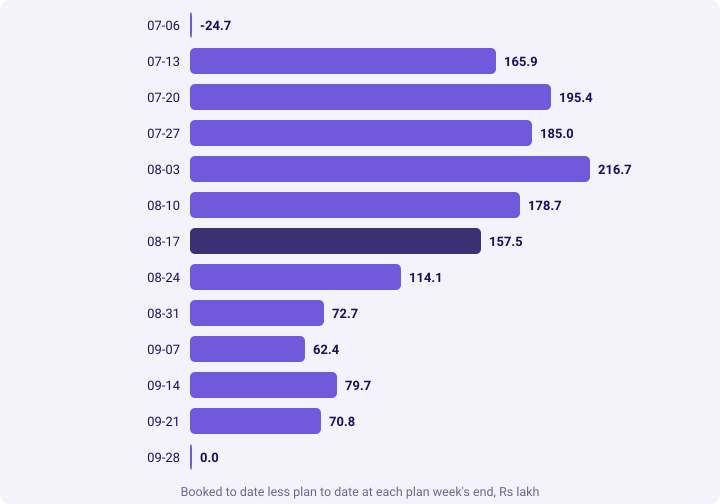

In [13]:
gap = [(str(r["week_start"])[5:], (r["booked_to_date"] - r["plan_to_date"]) / 1e5) for r in fixed]
kit.bars(gap, title="Booked to date less plan to date at each plan week's end, Rs lakh",
         fmt=lambda v: f"{v:,.1f}", lit=(6,))
kit.check("the lead peaked at the end of the week of 3 August",
          max(gap, key=lambda g: g[1])[0] == "08-03")

The lead was Rs 24.7 lakh behind after the first plan week, jumped ahead in the week of 13
July, peaked at Rs 2,16,69,660 at the end of the week of 3 August and shrank from there to Rs
10 at the close.

## What did this chapter answer?

1. **Which way, at what cost?** A running SUM in a window over weekly totals: the Q2 orders
   once, where plain sums per week read them 6,006 times.
2. **How much had Q2 booked by each week's end?** The plan-first build said the quarter closed
   Rs 15,39,810 short of plan, at Rs 9,68,60,180.
3. **Does it close on Monday's total?** Not until the plan's first week carries 1 to 5 July:
   then it closes on Rs 9,84,00,000, Rs 10 ahead of plan.
4. **Where was Q2 at mid-quarter?** Rs 1,57,51,980 ahead, built in one July week, with six of
   the seven full weeks from 10 August below plan.
5. **Can a running total by order name the order that crossed Rs 3.5 crore?** Only with a
   unique tiebreak: by date alone, twelve orders share one value.
6. **Does a plain sum agree?** Yes, in all thirteen weeks.

Chapter 6 brings the members back: Marketing wants to ring the flagged members on the protect
list, and one of them says they were on holiday.

In [14]:
kit.check_summary()